# Introduction

Phishing websites are one of the most common cyber threats faced by internet users today. Attackers create fraudulent websites that imitate legitimate organisations in order to steal sensitive information such as passwords, banking credentials, and personal data.

The objective of this project is to develop a machine learning model that can classify URLs as either legitimate or phishing based on URL characteristics and website features. This phishing detection capability will be integrated into ScamSense to help users identify potentially malicious links before becoming victims of online scams.

# Data Collection

The dataset used for this project is the PhiUSIIL Phishing URL Dataset.
Link: https://archive.ics.uci.edu/dataset/967/phiusiil+phishing+url+dataset

This dataset contains URL-based features extracted from both phishing and legitimate websites. The features include URL length, domain characteristics, HTTPS usage, redirection behaviour, and webpage security indicators.

The dataset is relevant because these characteristics are commonly used to distinguish phishing websites from legitimate websites.

In [1]:
#import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
#Load dataset
df = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")

df.head()

,URL,URLLength,Domain,DomainLength,IsDomainIP,URLSimilarityIndex,NoOfSubDomain,HasObfuscation,NoOfDegitsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,IsHTTPS,DomainTitleMatchScore,NoOfURLRedirect,HasExternalFormSubmit,HasPasswordField,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,100.0,1,0,0,0,0,1,1,0.000000,0,0,0,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,100.0,1,0,0,0,0,2,1,55.555556,0,0,0,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,100.0,2,0,0,0,0,2,1,46.666667,0,0,0,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,100.0,1,0,0,0,0,1,1,0.000000,0,0,0,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,100.0,1,0,0,0,0,1,1,100.000000,1,0,0,1


# Dataset Overview
before training a machine learning model, it is important to understand the structure and characteristics of the dataset.

The first step is to examine the number of records, available features, and data types.

In [3]:
df.shape

(235795, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 18 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  object 
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  object 
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  int64  
 5   URLSimilarityIndex          235795 non-null  float64
 6   NoOfSubDomain               235795 non-null  int64  
 7   HasObfuscation              235795 non-null  int64  
 8   NoOfDegitsInURL             235795 non-null  int64  
 9   NoOfQMarkInURL              235795 non-null  int64  
 10  NoOfAmpersandInURL          235795 non-null  int64  
 11  NoOfOtherSpecialCharsInURL  235795 non-null  int64  
 12  IsHTTPS                     235795 non-null  int64  
 13  DomainTitleMat

In [5]:
df.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,NoOfSubDomain,HasObfuscation,NoOfDegitsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,IsHTTPS,DomainTitleMatchScore,NoOfURLRedirect,HasExternalFormSubmit,HasPasswordField,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,1.164758,0.002057,1.881011,0.029403,0.025056,2.340198,0.782625,50.131427,0.133438,0.043987,0.102263,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.600969,0.045306,11.886695,0.193505,0.836448,3.527603,0.412461,49.676981,0.340048,0.205067,0.302994,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,75.000000,0.000000,0.000000,0.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000,1.000000,100.000000,0.000000,0.000000,0.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,10.000000,1.000000,2011.000000,4.000000,149.000000,499.000000,1.000000,100.000000,1.000000,1.000000,1.000000,1.000000


The dataset contains 235,795 records and 18 columns, including the target label used for phishing classification.

In [6]:
#Missing Values Check
df.isnull().sum()

URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
URLSimilarityIndex            0
NoOfSubDomain                 0
HasObfuscation                0
NoOfDegitsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
IsHTTPS                       0
DomainTitleMatchScore         0
NoOfURLRedirect               0
HasExternalFormSubmit         0
HasPasswordField              0
label                         0
dtype: int64

Missing value analysis was performed to determine whether data cleaning was required before model training.

# Exploratory Data Analysis (EDA)

EDA is performed to better understand the characteristics of the dataset and identify patterns that may be useful for phishing detection.

In [7]:
#Label Distribution
df['label'].value_counts()

label
1    134850
0    100945
Name: count, dtype: int64

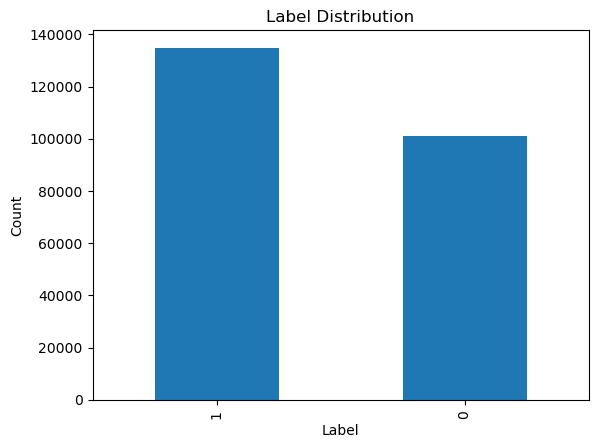

In [8]:
df['label'].value_counts().plot(kind='bar')

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

The label distribution was analysed to determine whether the dataset is balanced between phishing and legitimate websites. (Label 1 corresponds to a legitimate URL, label 0 to a phishing URL)

# Feature Analysis

URL length is one of the common indicators used in phishing detection because phishing websites often use unusually long URLs to hide malicious intentions.

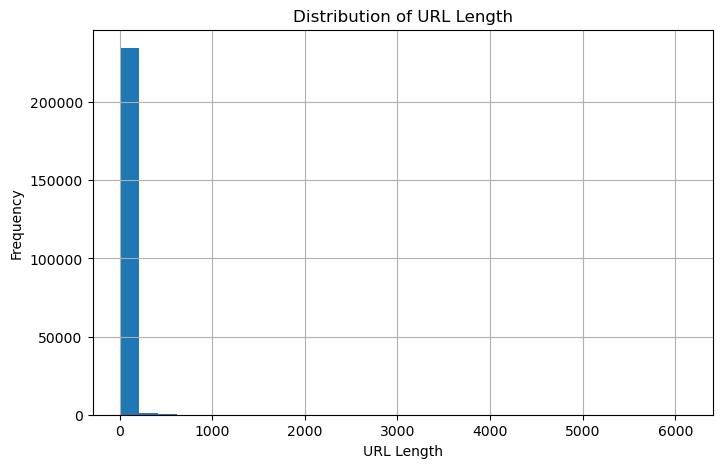

In [9]:
#URL Length Distribution
plt.figure(figsize=(8,5))

df['URLLength'].hist(bins=30)

plt.title("Distribution of URL Length")
plt.xlabel("URL Length")
plt.ylabel("Frequency")
plt.show()

Domain length is analysed because phishing websites may use unusually long or deceptive domain names that imitate legitimate websites.

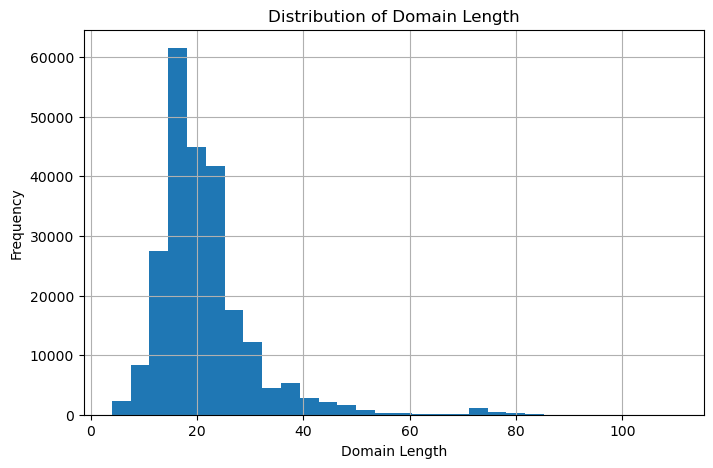

In [10]:
#Domain Length Distribution
plt.figure(figsize=(8,5))

df['DomainLength'].hist(bins=30)

plt.title("Distribution of Domain Length")
plt.xlabel("Domain Length")
plt.ylabel("Frequency")
plt.show()

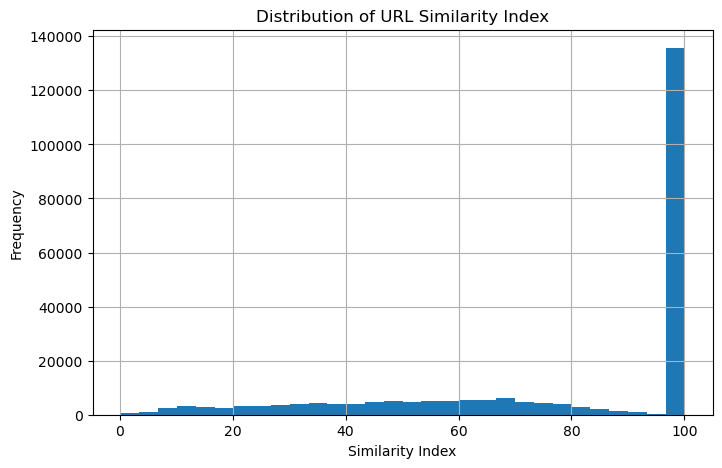

In [11]:
#URL Similarity Index
plt.figure(figsize=(8,5))

df['URLSimilarityIndex'].hist(bins=30)

plt.title("Distribution of URL Similarity Index")
plt.xlabel("Similarity Index")
plt.ylabel("Frequency")
plt.show()

The URL Similarity Index measures how closely a URL resembles legitimate websites. This feature can help identify impersonation attempts commonly used in phishing attacks.

# Feature Selection

Feature selection is performed to identify the most relevant attributes for phishing website detection.

The selected features focus on URL structure, domain characteristics, security indicators, and webpage behaviour.

In [12]:
#Feature Selection 
#Since URL and Domain are text fields, use the numerical features
selected_features = [

    'URLLength',
    'DomainLength',
    'IsDomainIP',
    'URLSimilarityIndex',
    'NoOfSubDomain',
    'HasObfuscation',
    'NoOfDegitsInURL',
    'NoOfQMarkInURL',
    'NoOfAmpersandInURL',
    'NoOfOtherSpecialCharsInURL',
    'IsHTTPS',
    'DomainTitleMatchScore',
    'NoOfURLRedirect',
    'HasExternalFormSubmit',
    'HasPasswordField'
]

In [13]:
X = df[selected_features]
y = df['label']

The selected features represent URL structure, domain characteristics, security indicators, and webpage behaviour that may indicate phishing activity.

# Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio.

The training set is used to teach the model while the testing set is used to evaluate performance on unseen data.

In [14]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
print(X_train.shape)
print(X_test.shape)

(188636, 15)
(47159, 15)


# Model Training

Random Forest was selected because it performs well on classification problems, can handle multiple numerical features, and provides good prediction accuracy while reducing overfitting.

In [16]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [17]:
#Predictions
y_pred = model.predict(X_test)

# Model Selection

Random Forest was selected because it performs well on classification problems, handles multiple features effectively, and reduces overfitting through ensemble learning.

In [18]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9998727708390763


In [19]:
#Precision
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.9997781147146925


In [20]:
#Recall
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 1.0


In [21]:
#F1 Score
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.9998890450477106


In [22]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20124
           1       1.00      1.00      1.00     27035

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



The classification report provides a detailed breakdown of precision, recall, and F1-score for each class.

# Confusion Matrix

The confusion matrix shows the number of correct and incorrect classifications made by the model.

In [23]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[20118     6]
 [    0 27035]]


# Conclusion

A Random Forest classification model was successfully trained using URL-based features from the PhiUSIIL Phishing URL Dataset. The model was evaluated using accuracy, precision, recall, and F1-score metrics. The results demonstrate the potential of machine learning techniques to identify phishing websites and support ScamSense in protecting users from online scams.

In [26]:
from joblib import dump

dump(model, 'phishing_model.pkl')

['phishing_model.pkl']

The high F1-score is mainly due to three reasons. First, the PhiUSIIL dataset contains phishing and legitimate URLs that are structurally different, making them relatively easy for the model to distinguish. Second, the training and testing data come from the same dataset distribution, meaning the test URLs are very similar in characteristics to the URLs the model was trained on. Third, the dataset is relatively balanced between phishing and legitimate samples, allowing both precision and recall to be high, which naturally leads to a high F1-score.